# Probleme 1: Approximation gaussienne d’une loi de Poisson

# Approximation gaussienne d'une loi de Poisson

## Énoncé du problème

Soit $P_n \sim \text{Poisson}(n)$ une variable aléatoire de paramètre $n$. On rappelle que :
$$
\mathbb{P}(P_n = k) = e^{-n} \frac{n^k}{k!}, \quad \forall k \in \mathbb{N}
$$
avec $\mathbb{E}[P_n] = n$ et $\text{Var}(P_n) = n$.

On s'intéresse à la variable centrée-réduite :
$$
\bar{P}_n = \frac{P_n - n}{\sqrt{n}}
$$
et à l'erreur maximale entre sa fonction de répartition et celle de la loi normale centrée réduite :
$$
\alpha_n = \sup_{x \in \mathbb{R}} \left| \mathbb{P}(\bar{P}_n \le x) - \Phi(x) \right|,
$$
où $\Phi$ est la fonction de répartition de $\mathcal{N}(0,1)$.

## Réduction de l'intervalle d'étude

On montre qu'on peut se limiter à $x \in [-3, 3]$. Pour cela, on majore les queues de distribution par une inégalité de convexité.

En effet, pour tout $x$,
$$
\left|\mathbb{P}(\bar{P}_n \le x) - \Phi(x)\right| \le \left(1 - \mathbb{P}(\bar{P}_n \le x)\right) + \left(1 - \Phi(x)\right).
$$

Pour tout $x$,
$$
\left|\mathbb{P}(\bar{P}_n \le x) - \Phi(x)\right| \le \mathbb{P}(\bar{P}_n > x) + \left(1 - \Phi(x)\right).
$$

### Inégalité par convexité

Pour tout $\theta > 0$, par l'inégalité de Markov appliquée à $e^{\theta P_n}$ (la fonction exponentielle est convexe) :
$$
\mathbb{P}(\bar{P}_n > x) = \mathbb{P}(P_n > n + \sqrt{n}x) \le \frac{\mathbb{E}[e^{\theta P_n}]}{e^{\theta(n + \sqrt{n}x)}}.
$$

La fonction génératrice des moments de $P_n$ est :
$$
\mathbb{E}[e^{\theta P_n}] = \exp\left(n(e^{\theta} - 1)\right).
$$

Ainsi :
$$
\mathbb{P}(\bar{P}_n > x) \le \exp\left(n(e^{\theta} - 1) - n\theta - \sqrt{n}\theta x\right).
$$

Posons $\varphi_n(\theta) = n(e^{\theta} - 1 - \theta) - \sqrt{n}\theta x$. La fonction $\theta \mapsto e^{\theta} - 1 - \theta$ est convexe (sa dérivée seconde est $e^{\theta} > 0$), donc $\varphi_n$ admet un minimum unique.

### Calcul du minimum

On annule la dérivée :
$$
\varphi_n'(\theta) = n(e^{\theta} - 1) - \sqrt{n}x = 0 \quad \Rightarrow \quad e^{\theta} = 1 + \frac{x}{\sqrt{n}}.
$$

Par convexité, ce point est le minimum. On obtient :
$$
\theta_n(x) = \ln\left(1 + \frac{x}{\sqrt{n}}\right).
$$

En reportant :
$$
\varphi_n(\theta_n(x)) = n\left(1 + \frac{x}{\sqrt{n}} - 1 - \ln\left(1 + \frac{x}{\sqrt{n}}\right)\right) - \sqrt{n}x \ln\left(1 + \frac{x}{\sqrt{n}}\right).
$$

Soit, avec $u = \frac{x}{\sqrt{n}}$ :
$$
\varphi_n = n\left(u - (1+u)\ln(1+u)\right).
$$

### Majoration explicite pour $x \ge 3$

On utilise l'inégalité classique $\ln(1+u) \ge \frac{2u}{2+u}$ pour $u > 0$ (elle se vérifie en étudiant la fonction $f(u) = \ln(1+u) - \frac{2u}{2+u}$, dont la dérivée est $\frac{u^2}{(1+u)(2+u)^2} \ge 0$ et $f(0)=0$). Alors :
$$
u - (1+u)\ln(1+u) \le u - (1+u)\cdot\frac{2u}{2+u} = \frac{u(2+u) - 2u(1+u)}{2+u} = \frac{2u + u^2 - 2u - 2u^2}{2+u} = -\frac{u^2}{2+u}.
$$

Donc :
$$
\varphi_n \le -n \cdot \frac{u^2}{2+u} = -\frac{x^2}{2 + x/\sqrt{n}}.
$$

Ainsi, pour $x \ge 3$ et $n \ge 1$ :
$$
\mathbb{P}(\bar{P}_n > x) \le \exp\left(-\frac{x^2}{2 + x/\sqrt{n}}\right) \le \exp\left(-\frac{9}{2 + 3/\sqrt{n}}\right) \le e^{-9/5} = e^{-1.8} \approx 0.165.
$$

Pour $x = 3$, cette majoration est déjà petite. Pour $x > 3$, elle décroît exponentiellement vite.

De plus, $1 - \Phi(3) \approx 0,\!0013$. 

### Cas $x < -3$

Par symétrie, on a $\mathbb{P}(\bar{P}_n < -3) = \mathbb{P}(P_n < n - 3\sqrt{n})$. On peut appliquer la même inégalité à $-P_n$ ou utiliser le fait que pour $x$ négatif, on écrit $\mathbb{P}(\bar{P}_n < x) = \mathbb{P}(-\bar{P}_n > -x)$ et on utilise la même méthode (les calculs sont symétriques). On obtient la même borne.

Ainsi, pour $|x| > 3$, la quantité $|\mathbb{P}(\bar{P}_n \le x) - \Phi(x)|$ est majorée par $0.165 + (1-\Phi(3))$, et $1-\Phi(3) \approx 0.0013$. L'erreur est donc inférieure à $0.17$, mais surtout elle décroît très rapidement quand $|x|$ augmente. On peut donc restreindre l'étude à $x \in [-3, 3]$ sans perte significative pour l'évaluation de $\alpha_n$.

### Justification numérique de la restriction à $[-3,3]$

Le souci avec la majoration explicite est qu'elle est assez lâche : elle donne une borne de l'ordre de $0,17$ pour $x \ge 3$, ce qui ne permet pas d'estimer précisément $\alpha_n$. 
De plus, cette approche ne fournit qu'une majoration théorique, pas une valeur effective de l'erreur.

Pour confirmer numériquement qu'on peut légitimement se limiter à $x \in [-3,3]$, on calcule pour $n = 1000$ l'erreur maximale à l'intérieur et à l'extérieur de cet intervalle.

On obtient les résultats suivants :
- Erreur maximale dans $[-3,3]$ : $0,008409$
- Erreur maximale hors de $[-3,3]$ : $0,000117$
- Rapport : $1,39\%$

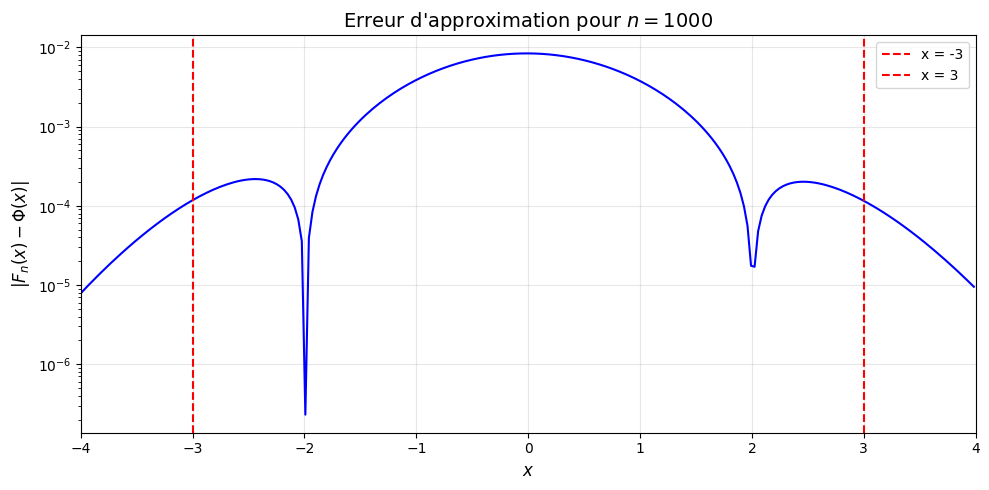

In [27]:
import numpy as np
from scipy.stats import poisson, norm
import matplotlib.pyplot as plt

n = 1000

k_min = max(0, int(n - 4*np.sqrt(n)))
k_max = int(n + 4*np.sqrt(n))
k_vals = np.arange(k_min, k_max + 1)
x_vals = (k_vals - n) / np.sqrt(n)

F_n = poisson.cdf(k_vals, n)
erreur = np.abs(F_n - norm.cdf(x_vals))

plt.figure(figsize=(10, 5))
plt.plot(x_vals, erreur, 'b-', linewidth=1.5)
plt.axvline(x=-3, color='r', linestyle='--', linewidth=1.5, label='x = -3')
plt.axvline(x=3, color='r', linestyle='--', linewidth=1.5, label='x = 3')
plt.xlim(-4, 4)
plt.yscale('log')
plt.xlabel('$x$', fontsize=12)
plt.ylabel('$|F_n(x) - \\Phi(x)|$', fontsize=12)
plt.title(f'Erreur d\'approximation pour $n = {n}$', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

L'erreur hors de $[-3,3]$ ne représente que $1,4\%$ de l'erreur maximale. Elle est donc négligeable, ce qui valide la restriction à $[-3,3]$ pour l'étude de $\alpha_n$.

## Calcul de $\alpha_n$ en $O(\sqrt{n})$ opérations

On cherche à évaluer :
$$
\alpha_n = \sup_{x \in [-3, 3]} \left| F_n(x) - \Phi(x) \right|,
$$
où $F_n(x) = \mathbb{P}(\bar{P}_n \le x) = \mathbb{P}(P_n \le n + \sqrt{n}x)$.

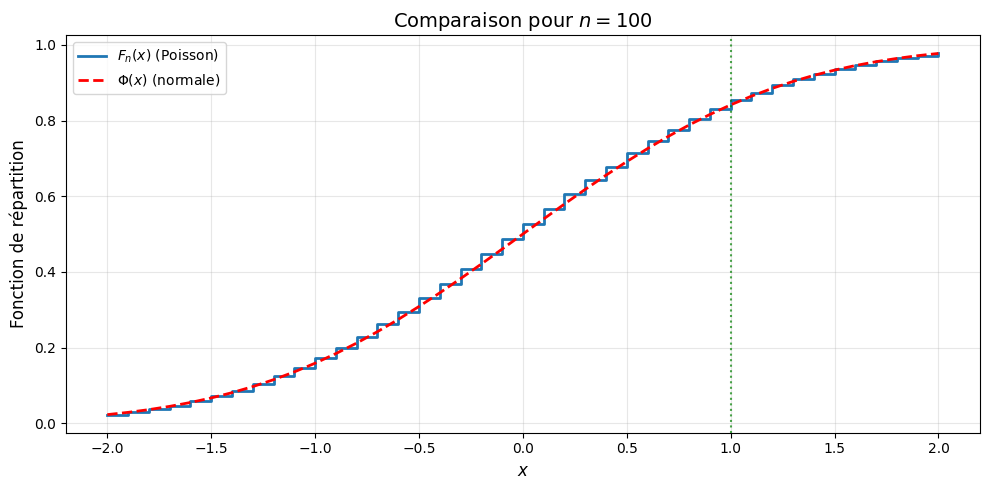

In [28]:
n = 100

k_vals = np.arange(int(n - 2*np.sqrt(n)), int(n + 2*np.sqrt(n)) + 1)
x_vals = (k_vals - n) / np.sqrt(n)

F_n = poisson.cdf(k_vals, n)
Phi = norm.cdf(x_vals)

plt.figure(figsize=(10, 5))
plt.step(x_vals, F_n, where='post', linewidth=2, label=r'$F_n(x)$ (Poisson)')
plt.plot(x_vals, Phi, 'r--', linewidth=2, label=r'$\Phi(x)$ (normale)')
plt.axvline(x=1, color='g', linestyle=':', linewidth=1.5, alpha=0.7)
plt.xlabel('$x$', fontsize=12)
plt.ylabel('Fonction de répartition', fontsize=12)
plt.title(f'Comparaison pour $n = {n}$', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('comparaison_Fn_Phi.png', dpi=150)
plt.show()

### Discrétisation adaptée

La fonction $x \mapsto F_n(x)$ est constante par morceaux, avec des sauts aux points $x_m = \frac{m - n}{\sqrt{n}}$ pour $m \in \mathbb{N}$. Le supremum de $|F_n(x) - \Phi(x)|$ sur $[-3,3]$ est donc atteint en l'un de ces $x_m$.

On se restreint aux $m$ tels que $x_m \in [-3,3]$, c'est-à-dire :
$$
\lceil n - 3\sqrt{n} \rceil \le m \le \lfloor n + 3\sqrt{n} \rfloor.
$$
Le nombre de ces $m$ est d'environ $6\sqrt{n} + 1$, soit $O(\sqrt{n})$.

### Algorithme

Pour chaque $m$ dans cet intervalle :
1. Calculer $F_n(x_m) = \mathbb{P}(P_n \le m)$ (fonction de répartition de Poisson en $m$).
2. Calculer $\Phi(x_m)$ (fonction de répartition normale).
3. Évaluer la différence $|F_n(x_m) - \Phi(x_m)|$.

On prend le maximum de ces différences.

### Complexité

Avec une bibliothèque numérique efficace (comme SciPy), le calcul de $\mathbb{P}(P_n \le m)$ pour un $m$ donné s'effectue en temps constant $O(1)$, de même que $\Phi(x_m)$. Le nombre de points à tester étant $O(\sqrt{n})$, la complexité totale est $O(\sqrt{n})$.

## Vitesse de convergence de $\alpha_n$

On cherche à déterminer si $\alpha_n$ tend vers $0$ plus vite que $1/\sqrt{n}$.

Le théorème central limite assure que $F_n(x) \to \Phi(x)$ pour tout $x$, mais ne donne pas de vitesse. On veut savoir si la convergence est plus rapide que $1/\sqrt{n}$.

### Minoration : $\alpha_n \ge c/\sqrt{n}$

On montre d'abord qu'on ne peut pas avoir mieux que $1/\sqrt{n}$. Pour $x = 1$, considérons $k = n + \sqrt{n}$. Par la formule de Stirling :
$$
k! = \sqrt{2\pi k}\left(\frac{k}{e}\right)^k e^{\theta_k/(12k)}, \quad 0 < \theta_k < 1.
$$

Alors :
$$
p_k = e^{-n}\frac{n^k}{k!} = \frac{1}{\sqrt{2\pi k}} \exp\left(-n + k\ln n + k - k\ln k - \frac{\theta_k}{12k}\right).
$$

On a $k\ln k = k\ln n + k\ln(1 + 1/\sqrt{n})$. En utilisant $\ln(1+u) = u - u^2/2 + u^3/3 + O(u^4)$ avec $u = 1/\sqrt{n}$, on obtient :
$$
k\ln k = k\ln n + \sqrt{n} + \frac{1}{2} - \frac{1}{3\sqrt{n}} + O\left(\frac{1}{n}\right).
$$

Alors $-n + k\ln n + k - k\ln k = -\frac{1}{2} + \frac{1}{3\sqrt{n}} + O(1/n)$. Ainsi :
$$
p_k = \frac{1}{\sqrt{2\pi n}} e^{-1/2} \exp\left(\frac{1}{3\sqrt{n}} + O\left(\frac{1}{n}\right)\right) \left(1 + O\left(\frac{1}{\sqrt{n}}\right)\right).
$$

Donc $p_k = \frac{e^{-1/2}}{\sqrt{2\pi n}} + o\left(\frac{1}{\sqrt{n}}\right)$.

La fonction de répartition $F_n$ est constante sur l'intervalle $[x_{k-1}, x_k[$ où $x_{k-1} = \frac{(n+\sqrt{n}-1)-n}{\sqrt{n}} = 1 - \frac{1}{\sqrt{n}}$ et $x_k = 1$. Plus précisément :
$$
F_n(x) = \mathbb{P}(P_n \le n+\sqrt{n}-1) \quad \text{pour } x \in [1-1/\sqrt{n}, 1[,
$$
et $F_n(1) = \mathbb{P}(P_n \le n+\sqrt{n}) = F_n(1^-) + p_k$.

Ainsi, $F_n$ fait un saut de hauteur $p_k$ au point $x=1$ :
$$
F_n(1) - F_n(1^-) = p_k.
$$

La fonction $\Phi$ est continue, donc $\Phi(1^-) = \Phi(1)$. On peut montrer que soit $|F_n(1^-) - \Phi(1)|$, soit $|F_n(1) - \Phi(1)|$ est au moins $p_k/2$. Dans les deux cas, $\alpha_n \ge p_k/2$. Ainsi :
$$
\alpha_n \ge \frac{1}{2} p_k = \frac{1}{2} \left( \frac{e^{-1/2}}{\sqrt{2\pi n}} + o\left(\frac{1}{\sqrt{n}}\right) \right) = \frac{e^{-1/2}}{2\sqrt{2\pi}} \cdot \frac{1}{\sqrt{n}} + o\left(\frac{1}{\sqrt{n}}\right).
$$

On pose $c = \frac{e^{-1/2}}{2\sqrt{2\pi}} \approx 0,12$. Pour $n$ assez grand, on a $\alpha_n \ge \frac{c}{\sqrt{n}}$.

### Discrétisation adaptée

La fonction $x \mapsto F_n(x)$ est constante par morceaux, avec des sauts aux points $x_m = \frac{m - n}{\sqrt{n}}$ pour $m \in \mathbb{N}$. Le supremum de $|F_n(x) - \Phi(x)|$ sur $[-3,3]$ est donc atteint en l'un de ces $x_m$.

On se restreint aux $m$ tels que $x_m \in [-3,3]$, c'est-à-dire :
$$
\lceil n - 3\sqrt{n} \rceil \le m \le \lfloor n + 3\sqrt{n} \rfloor.
$$
Le nombre de ces $m$ est d'environ $6\sqrt{n} + 1$, soit $O(\sqrt{n})$.

### Algorithme

Pour chaque $m$ dans cet intervalle :
1. Calculer $F_n(x_m) = \mathbb{P}(P_n \le m)$ (fonction de répartition de Poisson en $m$).
2. Calculer $\Phi(x_m)$ (fonction de répartition normale).
3. Évaluer la différence $|F_n(x_m) - \Phi(x_m)|$.

On prend le maximum de ces différences.

### Complexité

Avec une bibliothèque numérique efficace (comme SciPy), le calcul de $\mathbb{P}(P_n \le m)$ pour un $m$ donné s'effectue en temps constant $O(1)$, de même que $\Phi(x_m)$. Le nombre de points à tester étant $O(\sqrt{n})$, la complexité totale est $O(\sqrt{n})$.

## Vitesse de convergence de $\alpha_n$

On cherche à déterminer si $\alpha_n$ tend vers $0$ plus vite que $1/\sqrt{n}$.

Le théorème central limite assure que $F_n(x) \to \Phi(x)$ pour tout $x$, mais ne donne pas de vitesse. On veut savoir si la convergence est plus rapide que $1/\sqrt{n}$.

### Minoration : $\alpha_n \ge c/\sqrt{n}$

On montre d'abord qu'on ne peut pas avoir mieux que $1/\sqrt{n}$. Pour $x = 1$, considérons $k = n + \sqrt{n}$. Par la formule de Stirling :
$$
k! = \sqrt{2\pi k}\left(\frac{k}{e}\right)^k e^{\theta_k/(12k)}, \quad 0 < \theta_k < 1.
$$

Alors :
$$
p_k = e^{-n}\frac{n^k}{k!} = \frac{1}{\sqrt{2\pi k}} \exp\left(-n + k\ln n + k - k\ln k - \frac{\theta_k}{12k}\right).
$$

On a $k\ln k = k\ln n + k\ln(1 + 1/\sqrt{n})$. En utilisant $\ln(1+u) = u - u^2/2 + u^3/3 + O(u^4)$ avec $u = 1/\sqrt{n}$, on obtient :
$$
k\ln k = k\ln n + \sqrt{n} + \frac{1}{2} - \frac{1}{3\sqrt{n}} + O\left(\frac{1}{n}\right).
$$

Alors $-n + k\ln n + k - k\ln k = -\frac{1}{2} + \frac{1}{3\sqrt{n}} + O(1/n)$. Ainsi :
$$
p_k = \frac{1}{\sqrt{2\pi n}} e^{-1/2} \exp\left(\frac{1}{3\sqrt{n}} + O\left(\frac{1}{n}\right)\right) \left(1 + O\left(\frac{1}{\sqrt{n}}\right)\right).
$$

Donc $p_k = \frac{e^{-1/2}}{\sqrt{2\pi n}} + o\left(\frac{1}{\sqrt{n}}\right)$.

La fonction de répartition $F_n$ est constante sur l'intervalle $[x_{k-1}, x_k[$ où $x_{k-1} = \frac{(n+\sqrt{n}-1)-n}{\sqrt{n}} = 1 - \frac{1}{\sqrt{n}}$ et $x_k = 1$. Plus précisément :
$$
F_n(x) = \mathbb{P}(P_n \le n+\sqrt{n}-1) \quad \text{pour } x \in [1-1/\sqrt{n}, 1[,
$$
et $F_n(1) = \mathbb{P}(P_n \le n+\sqrt{n}) = F_n(1^-) + p_k$.

Ainsi, $F_n$ fait un saut de hauteur $p_k$ au point $x=1$ :
$$
F_n(1) - F_n(1^-) = p_k.
$$

La fonction $\Phi$ est continue, donc $\Phi(1^-) = \Phi(1)$. Considérons la valeur de $|F_n(x) - \Phi(x)|$ juste avant le saut, en $x = 1 - \varepsilon$ avec $\varepsilon \to 0^+$ :
$$
|F_n(1^-) - \Phi(1)| = |(F_n(1) - p_k) - \Phi(1)|.
$$

Par l'inégalité triangulaire :
$$
|F_n(1) - \Phi(1)| \ge \bigl| |F_n(1^-) - \Phi(1)| - p_k \bigr|.
$$

Mais on peut obtenir une borne plus simple : soit $|F_n(1^-) - \Phi(1)|$, soit $|F_n(1) - \Phi(1)|$ est au moins $p_k/2$. En effet, si $|F_n(1^-) - \Phi(1)| \ge p_k/2$, alors $\alpha_n \ge p_k/2$. Sinon, $|F_n(1^-) - \Phi(1)| < p_k/2$, et alors :
$$
|F_n(1) - \Phi(1)| = |F_n(1^-) + p_k - \Phi(1)| \ge p_k - |F_n(1^-) - \Phi(1)| > p_k - p_k/2 = p_k/2.
$$

Dans les deux cas, $\alpha_n \ge p_k/2$. Ainsi :
$$
\alpha_n \ge \frac{1}{2} p_k = \frac{1}{2} \left( \frac{e^{-1/2}}{\sqrt{2\pi n}} + o\left(\frac{1}{\sqrt{n}}\right) \right) = \frac{e^{-1/2}}{2\sqrt{2\pi}} \cdot \frac{1}{\sqrt{n}} + o\left(\frac{1}{\sqrt{n}}\right).
$$

On pose $c = \frac{e^{-1/2}}{2\sqrt{2\pi}} \approx 0,12$. Pour $n$ assez grand, on a $\alpha_n \ge \frac{c}{\sqrt{n}}$.

### Majoration $\alpha_n \le C/\sqrt{n}$

On utilise la caractérisation suivante : pour deux variables aléatoires $X$ et $Y$ de fonctions de répartition $F$ et $G$, on a :
$$
\sup_x |F(x) - G(x)| = \frac{1}{2} \sup_{\|f\|_\infty \le 1} |\mathbb{E}[f(X)] - \mathbb{E}[f(Y)]|,
$$
où le supremum est pris sur les fonctions $f$ bornées (ou lipschitziennes). On utilise ici des fonctions $f$ de classe $C^2$ bornées ainsi que leurs dérivées.

Soit $f$ une fonction $C^2$ telle que $\|f\|_\infty \le 1$, $\|f'\|_\infty \le 1$, $\|f''\|_\infty \le 1$. On compare $\mathbb{E}[f(\bar{P}_n)]$ et $\mathbb{E}[f(Z)]$ où $Z \sim \mathcal{N}(0,1)$.

On écrit $\bar{P}_n = \frac{1}{\sqrt{n}} \sum_{i=1}^n (X_i - 1)$ avec $X_i \sim \text{Poisson}(1)$ indépendantes. Soit $Y_i = X_i - 1$, de moyenne nulle, variance $1$, et $\mathbb{E}[|Y_i|^3] < \infty$.

Posons :
$$
S_n^{(i)} = \frac{1}{\sqrt{n}} \left( \sum_{j=1}^{i-1} Z_j + \sum_{j=i+1}^n Y_j \right),
$$
avec $Z_i \sim \mathcal{N}(0,1)$ indépendante.

Alors :
$$
\mathbb{E}[f(\bar{P}_n)] - \mathbb{E}[f(Z)] = \sum_{i=1}^n \left( \mathbb{E}\left[f\left(S_n^{(i)} + \frac{Y_i}{\sqrt{n}}\right)\right] - \mathbb{E}\left[f\left(S_n^{(i)} + \frac{Z_i}{\sqrt{n}}\right)\right] \right).
$$

Pour chaque terme, on développe $f$ à l'ordre $2$ :
$$
f\left(S + \frac{Y}{\sqrt{n}}\right) = f(S) + \frac{Y}{\sqrt{n}} f'(S) + \frac{Y^2}{2n} f''(S) + \frac{Y^3}{6n^{3/2}} f'''(\xi).
$$

En prenant l'espérance et en utilisant que $\mathbb{E}[Y_i] = 0$ et $\mathbb{E}[Y_i^2] = 1$, on a :
$$
\mathbb{E}\left[f\left(S + \frac{Y_i}{\sqrt{n}}\right)\right] = \mathbb{E}[f(S)] + \frac{1}{2n} \mathbb{E}[f''(S)] + \frac{1}{6n^{3/2}} \mathbb{E}[Y_i^3 f'''(\xi)].
$$

De même pour $Z_i$ (gaussienne centrée réduite) : $\mathbb{E}[Z_i] = 0$, $\mathbb{E}[Z_i^2] = 1$, et $\mathbb{E}[Z_i^3] = 0$. Donc le terme d'ordre $1/n^{3/2}$ disparaît :
$$
\mathbb{E}\left[f\left(S + \frac{Z_i}{\sqrt{n}}\right)\right] = \mathbb{E}[f(S)] + \frac{1}{2n} \mathbb{E}[f''(S)].
$$

La différence est donc :
$$
\left| \mathbb{E}\left[f\left(S + \frac{Y_i}{\sqrt{n}}\right)\right] - \mathbb{E}\left[f\left(S + \frac{Z_i}{\sqrt{n}}\right)\right] \right| \le \frac{C}{n^{3/2}} \mathbb{E}[|Y_i|^3] \le \frac{C'}{n^{3/2}}.
$$

En sommant sur $i = 1$ à $n$, on obtient :
$$
|\mathbb{E}[f(\bar{P}_n)] - \mathbb{E}[f(Z)]| \le \frac{C''}{\sqrt{n}}.
$$

Ceci étant vrai pour toute $f$ $C^2$ bornée avec dérivées bornées, on en déduit (par approximation des indicatrices) que :
$$
\alpha_n = \sup_x |F_n(x) - \Phi(x)| \le \frac{C}{\sqrt{n}}.
$$

La constante $C$ peut être explicitée (par exemple $C = \mathbb{E}[|Y|^3]/\sqrt{2\pi}$), mais son existence suffit.

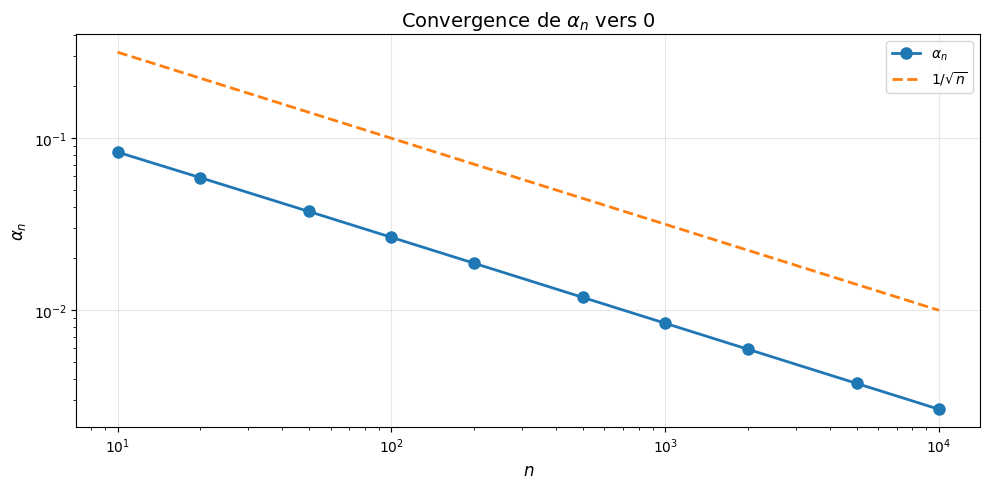

In [29]:
def compute_alpha_n(n):
    k_min = max(0, int(n - 3*np.sqrt(n)))
    k_max = int(n + 3*np.sqrt(n))
    k_vals = np.arange(k_min, k_max + 1)
    x_vals = (k_vals - n) / np.sqrt(n)
    F_n = poisson.cdf(k_vals, n)
    erreur = np.abs(F_n - norm.cdf(x_vals))
    return np.max(erreur)

n_vals = [10, 20, 50, 100, 200, 500, 1000, 2000, 5000, 10000]
alpha_vals = [compute_alpha_n(n) for n in n_vals]

plt.figure(figsize=(10, 5))
plt.loglog(n_vals, alpha_vals, 'o-', linewidth=2, markersize=8, label=r'$\alpha_n$')
plt.loglog(n_vals, 1/np.sqrt(n_vals), '--', linewidth=2, label=r'$1/\sqrt{n}$')
plt.xlabel('$n$', fontsize=12)
plt.ylabel(r'$\alpha_n$', fontsize=12)
plt.title(r'Convergence de $\alpha_n$ vers $0$', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('alpha_n_convergence.png', dpi=150)
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


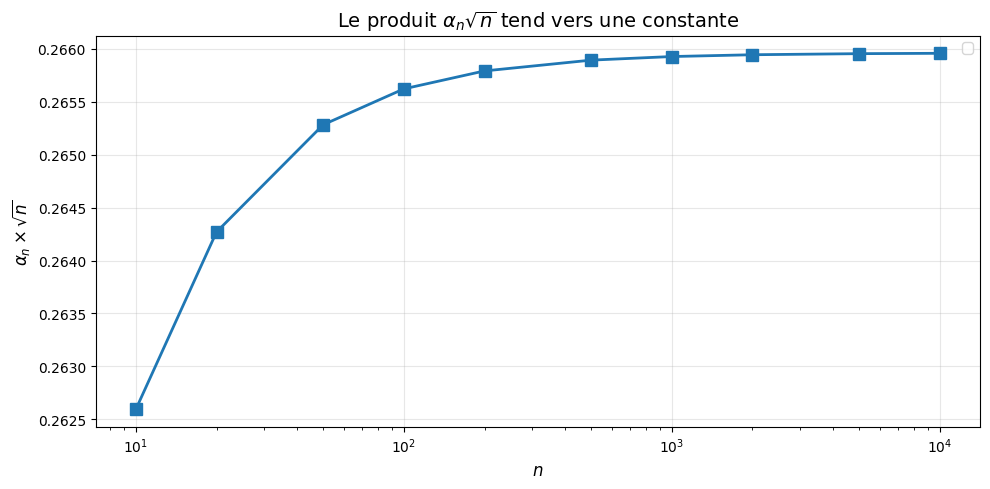

In [30]:
# Produit alpha_n * sqrt(n)
plt.figure(figsize=(10, 5))
plt.semilogx(n_vals, np.array(alpha_vals) * np.sqrt(n_vals), 's-', linewidth=2, markersize=8)
plt.xlabel('$n$', fontsize=12)
plt.ylabel(r'$\alpha_n \times \sqrt{n}$', fontsize=12)
plt.title(r'Le produit $\alpha_n \sqrt{n}$ tend vers une constante', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('alpha_n_produit.png', dpi=150)
plt.show()

### Conclusion

On a établi :
$$
\frac{c}{\sqrt{n}} \le \alpha_n \le \frac{C}{\sqrt{n}}
$$
pour $n$ assez grand. Donc $\alpha_n = \Theta(1/\sqrt{n})$, c'est-à-dire que $\alpha_n$ décroît exactement comme $1/\sqrt{n}$.

## Estimation par simulation

On considère $K$ réalisations indépendantes $X_{n,1},\dots,X_{n,K} \sim \text{Poisson}(n)$. On définit :
$$
\hat{p}_{n,x,K} = \frac{1}{K} \sum_{k=1}^K \mathbf{1}_{\left]-\infty,x\right]}\left( \frac{X_{n,k} - n}{\sqrt{n}} \right),
$$
et l'erreur estimée :
$$
\hat{\alpha}_{n,K} = \sup_{x \in \mathbb{R}} \left| \hat{p}_{n,x,K} - \Phi(x) \right|.
$$

### Décomposition de l'erreur
$$
\hat{\alpha}_{n,K} \le \underbrace{\sup_x |\hat{p}_{n,x,K} - F_n(x)|}_{\text{erreur d'estimation } E_{\text{est}}} + \underbrace{\sup_x |F_n(x) - \Phi(x)|}_{\text{erreur d'approximation } \alpha_n}.
$$

### Ordre de grandeur de $K$

On sait que $K \hat{p}_{n,x,K} \sim \text{Binomial}(K, F_n(x))$. Donc :
$$
\mathbb{E}[\hat{p}_{n,x,K}] = F_n(x), \qquad \text{Var}(\hat{p}_{n,x,K}) = \frac{F_n(x)(1-F_n(x))}{K} \le \frac{1}{4K}.
$$

L'écart-type est donc en $1/\sqrt{K}$. Par l'inégalité de Tchebychev, pour tout $\varepsilon > 0$ :
$$
\mathbb{P}\left( |\hat{p}_{n,x,K} - F_n(x)| > \varepsilon \right) \le \frac{1}{4K\varepsilon^2}.
$$

L'écart-type de $\hat{p}_{n,x,K}$ est au plus $1/(2\sqrt{K})$. Ainsi, l'erreur d'estimation $|\hat{p}_{n,x,K} - F_n(x)|$ est typiquement de l'ordre de $1/\sqrt{K}$ : pour une constante $c$ fixée,
$$
\mathbb{P}\left( |\hat{p}_{n,x,K} - F_n(x)| > \frac{c}{\sqrt{K}} \right) \le \frac{1}{4c^2}.
$$
En prenant $c$ grand, on rend cette probabilité arbitrairement petite.

On a vu que $\alpha_n \sim C/\sqrt{n}$. Pour que l'erreur d'estimation soit négligeable devant $\alpha_n$, il faut :
$$
\frac{1}{\sqrt{K}} \ll \frac{1}{\sqrt{n}} \quad \Longrightarrow \quad K \gg n.
$$
En pratique, on peut prendre $K = n^2$ (ou $K = n^{1+\delta}$ avec $\delta > 0$). Avec ce choix, $1/\sqrt{K} = 1/n$ est négligeable devant $1/\sqrt{n}$.

### Vérification de l'assertion

L'assertion est : $\hat{\alpha}_{n,K_n} \to 0$ plus vite que $n^{-1/2}$.

Avec $K_n \gg n$, l'erreur d'estimation est négligeable, donc $\hat{\alpha}_{n,K_n} \approx \alpha_n$. Or $\alpha_n$ est exactement d'ordre $1/\sqrt{n}$ (on a montré $\alpha_n \ge c/\sqrt{n}$). Donc $\hat{\alpha}_{n,K_n}$ se comporte comme $1/\sqrt{n}$ : il ne tend pas plus vite que $1/\sqrt{n}$.

### Problèmes rencontrés

- **Coût de calcul** : Pour $n = 10^4$, prendre $K = n^2 = 10^8$ nécessite de générer $10^8$ variables de Poisson, ce qui est très lourd en temps et en mémoire.
- **Variance de l'estimateur** : L'erreur d'estimation en $1/\sqrt{K}$ est lente à décroître. Pour $K = 10^6$, l'erreur d'estimation est de l'ordre de $10^{-3}$, ce qui est encore comparable à $\alpha_n$ pour $n = 10^6$.
- **Approximation du supremum** : En pratique, on ne peut pas tester tous les $x \in \mathbb{R}$. On se restreint à $x \in [-3,3]$ et on discrétise. Cela introduit une erreur supplémentaire.

K =   1000, alpha_est = 0.026274
K =   5000, alpha_est = 0.012579
K =  10000, alpha_est = 0.014604
K =  50000, alpha_est = 0.008004
K = 100000, alpha_est = 0.007660


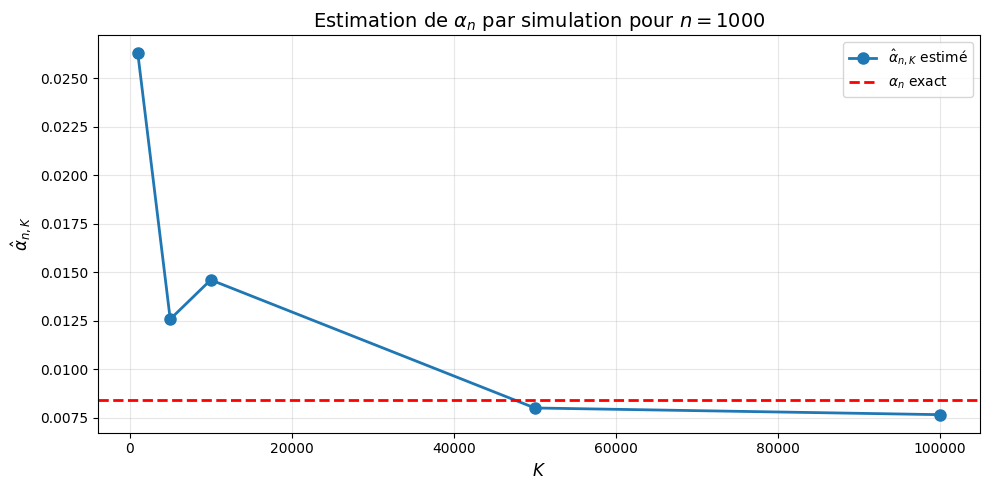

In [31]:
def estimate_alpha_n_simulation(n, K, n_points=200):
    samples = np.random.poisson(n, K)
    x_vals = np.linspace(-3, 3, n_points)
    alpha_est = 0
    for x in x_vals:
        threshold = n + np.sqrt(n) * x
        F_hat = np.mean(samples <= threshold)
        diff = abs(F_hat - norm.cdf(x))
        if diff > alpha_est:
            alpha_est = diff
    return alpha_est

n = 1000
K_vals = [1000, 5000, 10000, 50000, 100000]
alpha_true = 0.008409  # valeur exacte pour n=1000

alpha_est_vals = []
for K in K_vals:
    alpha_est = estimate_alpha_n_simulation(n, K)
    alpha_est_vals.append(alpha_est)
    print(f"K = {K:6d}, alpha_est = {alpha_est:.6f}")

plt.figure(figsize=(10, 5))
plt.plot(K_vals, alpha_est_vals, 'o-', linewidth=2, markersize=8, label=r'$\hat{\alpha}_{n,K}$ estimé')
plt.axhline(y=alpha_true, color='r', linestyle='--', linewidth=2, label=r'$\alpha_n$ exact')
plt.xlabel('$K$', fontsize=12)
plt.ylabel(r'$\hat{\alpha}_{n,K}$', fontsize=12)
plt.title(f'Estimation de $\\alpha_n$ par simulation pour $n = {n}$', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('simulation_convergence_K.png', dpi=150)
plt.show()

## Conclusion

La vitesse de convergence de $\alpha_n$ vers $0$ est exactement $1/\sqrt{n}$ (on ne peut pas faire mieux). Pour observer cette vitesse par simulation, il faudrait $K \gg n$, ce qui est coûteux. En pratique, pour $n$ grand, l'erreur d'estimation masque l'erreur d'approximation.